## IMPORT LIBRARIES AND DATA

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\USER\Downloads\diabetes.csv") 
df.head()


## EXPLORATORY DATA ANALYSIS (EDA)

In [7]:
# Columns where zero is likely invalid
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Check number of zeros in these columns
for col in zero_cols:
    print(f"{col} has {(df[col] == 0).sum()} zero values")


Glucose has 0 zero values
BloodPressure has 0 zero values
SkinThickness has 0 zero values
Insulin has 0 zero values
BMI has 0 zero values


In [8]:
# Replace zeros with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

In [9]:
# Fill NaN values with column median
df.fillna(df.median(), inplace=True)

In [10]:
# Confirm there are no missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [11]:
# Preview the cleaned DataFrame
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [12]:

print("\nBasic Description:\n", )
df.describe().T


Basic Description:



,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [13]:

# 1. Average glucose level for diabetics vs non-diabetics
avg_glucose = df.groupby('Outcome')['Glucose'].mean()

# 2. Do people with more pregnancies tend to have diabetes more often?
preg_mean = df.groupby('Outcome')['Pregnancies'].mean()

# 3. Average BMI of diabetics vs non-diabetics
avg_bmi = df.groupby('Outcome')['BMI'].mean()

# 4. Relationship between high glucose and diabetes
high_glucose = df[df['Glucose'] > 140]['Outcome'].value_counts(normalize=True)  # >140 = high

# 5. Relationship between BMI and diabetes
high_bmi = df[df['BMI'] > 30]['Outcome'].value_counts(normalize=True)  # >30 = obese

# 6. Relationship between skin thickness and diabetes
skin_corr = df['SkinThickness'].corr(df['Outcome'])

# 7. Age range more at risk
age_risk = df.groupby('Outcome')['Age'].mean()

# 8. Low blood pressure reduce diabetes risk?
low_bp = df[df['BloodPressure'] < 70]['Outcome'].value_counts(normalize=True)

# 9. Diabetes more common in people with >3 pregnancies?
more_preg = df[df['Pregnancies'] > 3]['Outcome'].value_counts(normalize=True)

# 10. Diabetes pedigree (family history score) relation
ped_corr = df['DiabetesPedigreeFunction'].corr(df['Outcome'])

# Display all results
print("\n1. Average Glucose Level:\n", avg_glucose)
print("\n2. Average Pregnancies:\n", preg_mean)
print("\n3. Average BMI:\n", avg_bmi)
print("\n4. Proportion of Diabetics with High Glucose (>140):\n", high_glucose)
print("\n5. Proportion of Diabetics with High BMI (>30):\n", high_bmi)
print("\n6. Correlation between Skin Thickness and Diabetes:\n", skin_corr)
print("\n7. Average Age by Outcome:\n", age_risk)
print("\n8. Diabetes Rate for Low Blood Pressure (<70):\n", low_bp)
print("\n9. Diabetes Rate for >3 Pregnancies:\n", more_preg)
print("\n10. Correlation between Family History (Pedigree) and Diabetes:\n", ped_corr)



1. Average Glucose Level:
 Outcome
0    110.622000
1    142.302239
Name: Glucose, dtype: float64

2. Average Pregnancies:
 Outcome
0    3.298000
1    4.865672
Name: Pregnancies, dtype: float64

3. Average BMI:
 Outcome
0    30.846000
1    35.398507
Name: BMI, dtype: float64

4. Proportion of Diabetics with High Glucose (>140):
 Outcome
1    0.6875
0    0.3125
Name: proportion, dtype: float64

5. Proportion of Diabetics with High BMI (>30):
 Outcome
0    0.544118
1    0.455882
Name: proportion, dtype: float64

6. Correlation between Skin Thickness and Diabetes:
 0.29513764691994476

7. Average Age by Outcome:
 Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64

8. Diabetes Rate for Low Blood Pressure (<70):
 Outcome
0    0.75265
1    0.24735
Name: proportion, dtype: float64

9. Diabetes Rate for >3 Pregnancies:
 Outcome
0    0.549419
1    0.450581
Name: proportion, dtype: float64

10. Correlation between Family History (Pedigree) and Diabetes:
 0.17384406565295996


In [14]:
#  Compute correlation matrix
correlation = df.corr()

# Show correlation of all features with 'Outcome' (diabetes)
outcome_corr = correlation['Outcome'].sort_values(ascending=False)
print("Linear Relationship with Outcome (Diabetes):\n")
print(outcome_corr)

Linear Relationship with Outcome (Diabetes):

Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


Text(0.5, 1.0, 'Glucose Levels by Diabetes Status')

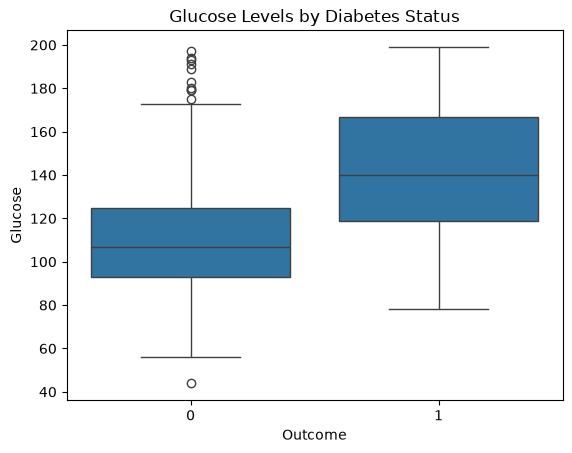

In [16]:
# Plot 1: Average Glucose Level - Diabetics vs Non-diabetics
plt.figure()
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose Levels by Diabetes Status")


<Axes: title={'center': 'Distribution of Diabetes Outcome'}, xlabel='Outcome'>

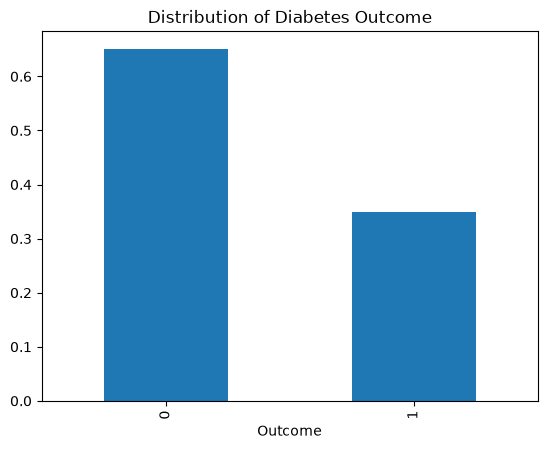

In [17]:


df['Outcome'].value_counts(normalize=True).plot(kind='bar', title='Distribution of Diabetes Outcome')

C:\Users\USER\AppData\Local\Temp\ipykernel_15904\3012504987.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='Set2')


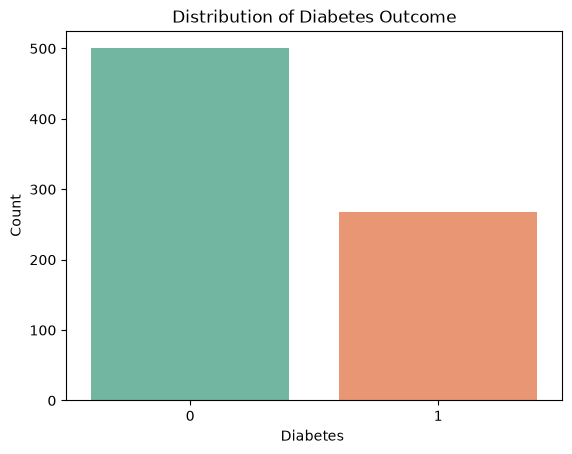

In [18]:
sns.countplot(data=df, x='Outcome', palette='Set2')
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Diabetes ')
plt.ylabel('Count')
plt.show()

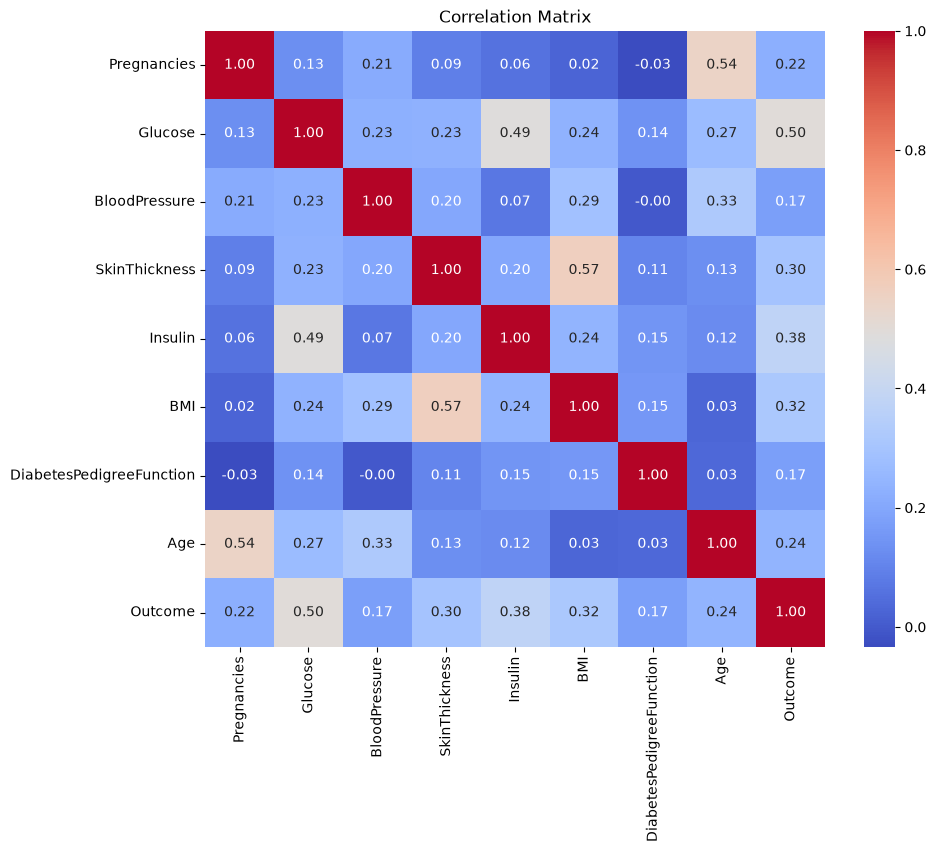

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_15904\2734535344.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette='Set3')


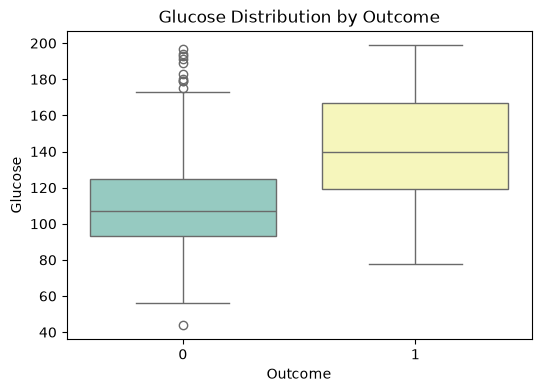

C:\Users\USER\AppData\Local\Temp\ipykernel_15904\2734535344.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette='Set3')


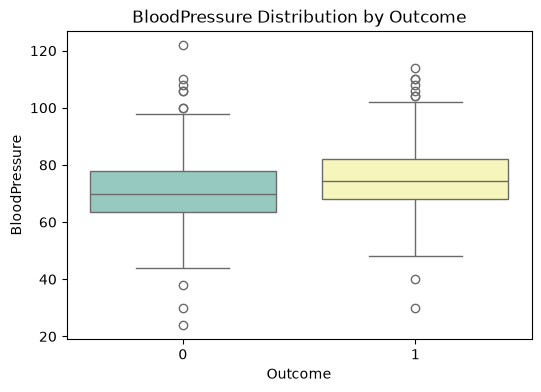

C:\Users\USER\AppData\Local\Temp\ipykernel_15904\2734535344.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette='Set3')


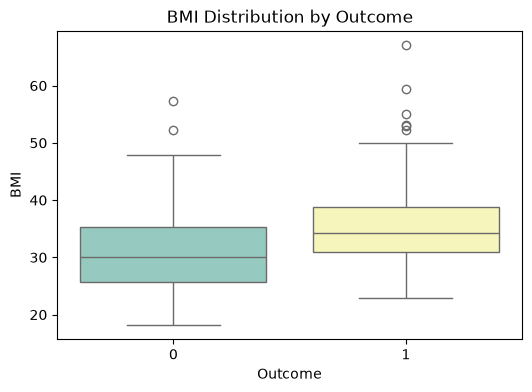

C:\Users\USER\AppData\Local\Temp\ipykernel_15904\2734535344.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette='Set3')


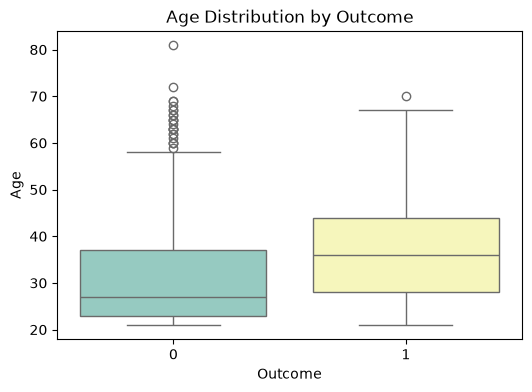

C:\Users\USER\AppData\Local\Temp\ipykernel_15904\2734535344.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y=col, palette='Set3')


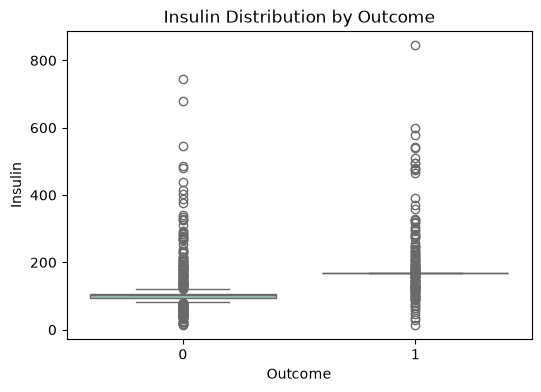

In [20]:
features = ['Glucose', 'BloodPressure', 'BMI', 'Age', 'Insulin']
for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='Outcome', y=col, palette='Set3')
    plt.title(f'{col} Distribution by Outcome')
    plt.show()


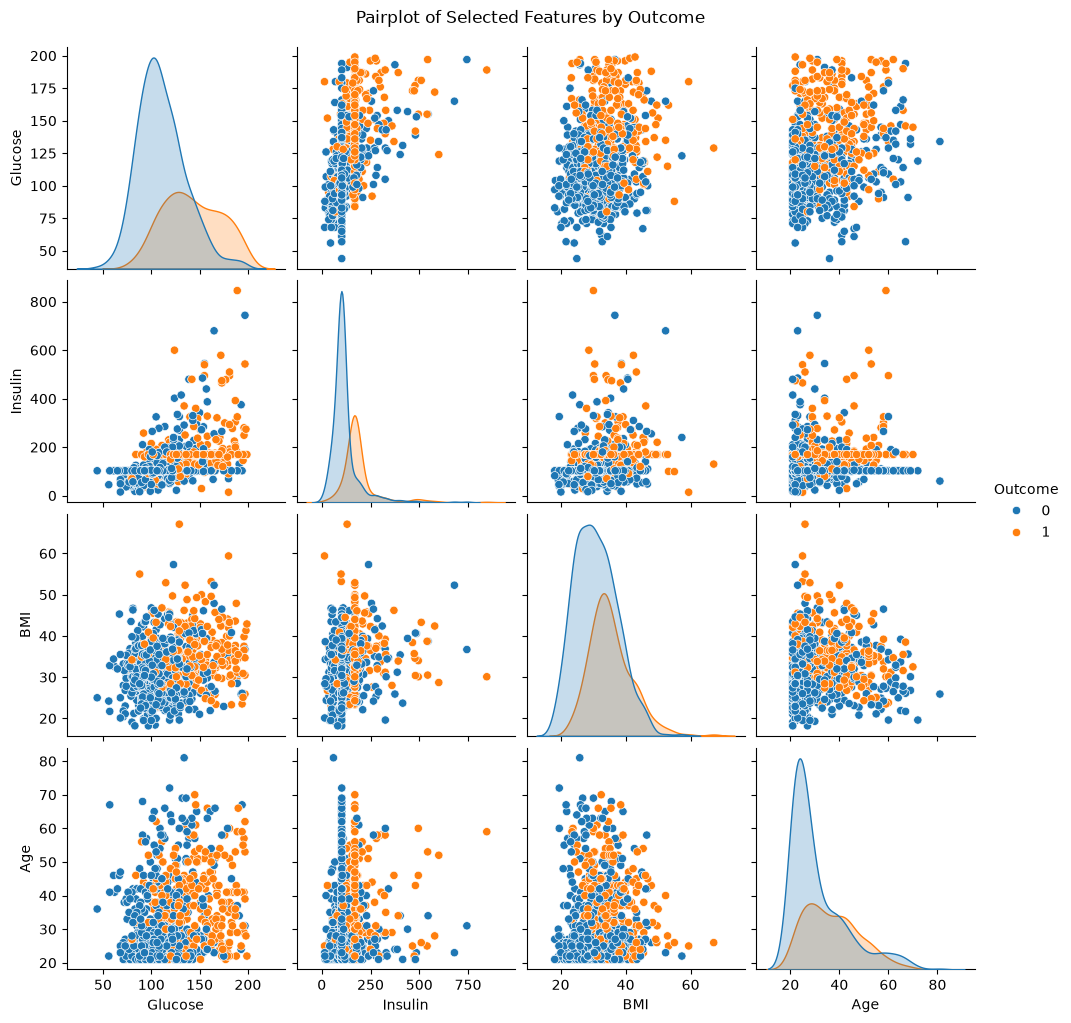

In [21]:
sns.pairplot(df, hue='Outcome', vars=['Glucose', 'Insulin', 'BMI', 'Age'])
plt.suptitle("Pairplot of Selected Features by Outcome", y=1.02)
plt.show()


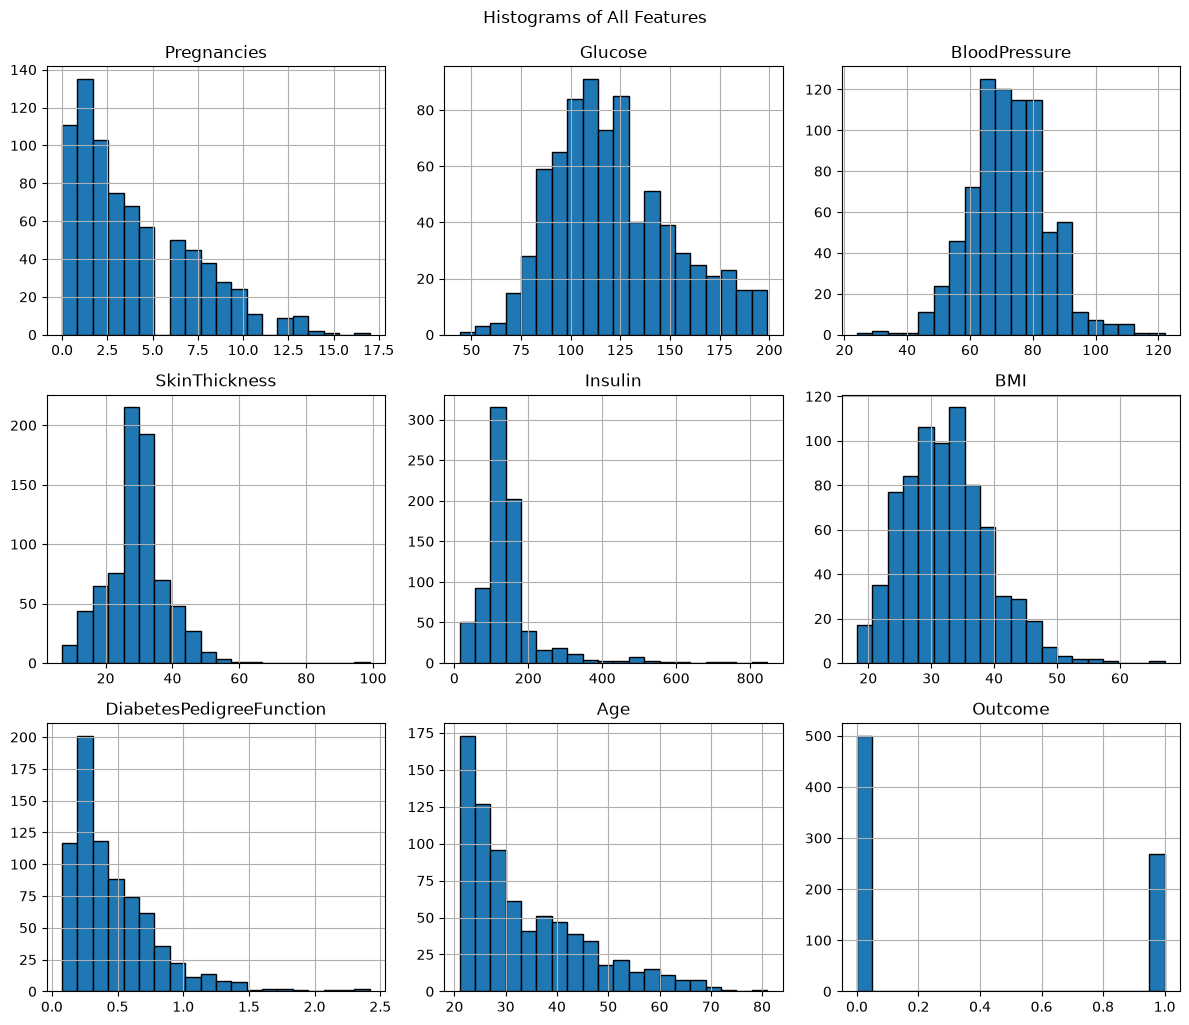

In [22]:
# 5. HISTOGRAMS / DISTRIBUTIONS
# -------------------------------
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.suptitle('Histograms of All Features', y=1.02)
plt.show()

Text(0.5, 1.0, 'Distribution of BMI by Diabetes Status')

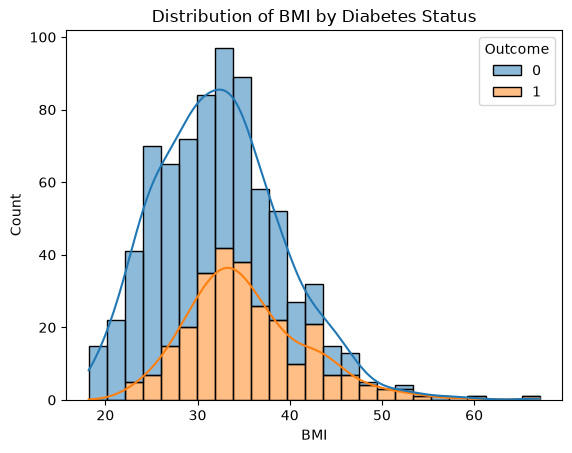

In [23]:
# Plot 5: Relationship between BMI and Diabetes
plt.figure()
sns.histplot(data=df, x='BMI', hue='Outcome', kde=True, multiple='stack')
plt.title("Distribution of BMI by Diabetes Status")

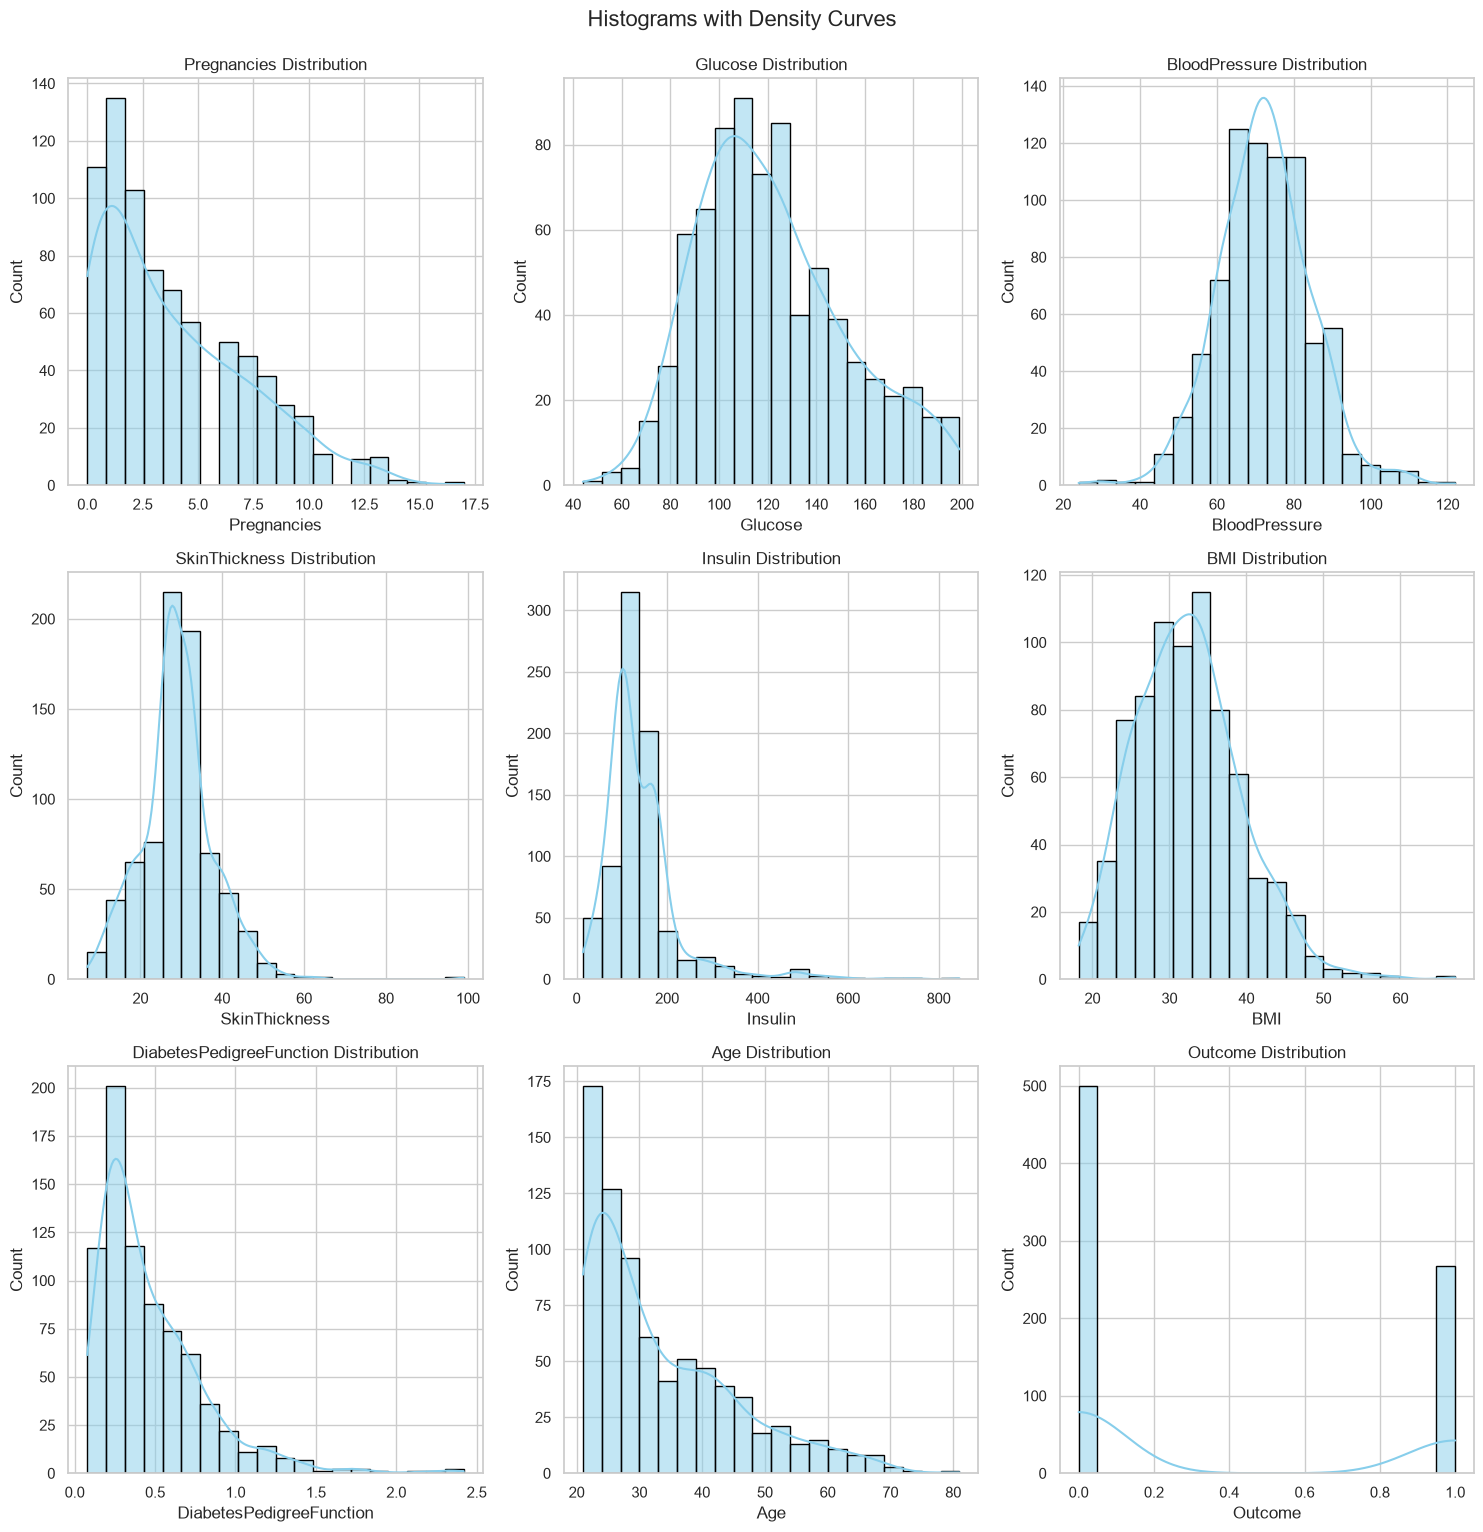

In [24]:
# Set the style
sns.set(style="whitegrid")

# Create histograms with density lines for each numeric feature
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, 15))

for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(
        df[col],
        kde=True,
        bins=20,
        color='skyblue',             # Color of histogram bars
        edgecolor='black',
        line_kws={'color': 'green'}   # Color of the density (KDE) line
    )
    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.suptitle('Histograms with Density Curves', fontsize=16, y=1.02)
plt.show()

In [25]:
# Separate features and target variable

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (768, 8)
Target shape: (768,)


In [26]:
#Spilting the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


Training features: (614, 8)
Testing features: (154, 8)
Training target: (614,)
Testing target: (154,)


In [29]:
#Scaling the numerical features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Fitting the scaler only on the training data
scaler.fit(X_train)

#Before transforming the dataset again to avoid leaking 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



## MODEL TRANING AND EVALUATION

In [31]:
#Training Logistic regression
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]


In [32]:
# Training Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]


In [33]:
#Training Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]


In [34]:
#Evaluating the different models with various evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model_name, y_test, y_pred, y_prob):

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return results


In [35]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt,
        y_prob_dt
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)


In [36]:
results_df = pd.DataFrame(results)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429,0.826296
1,Decision Tree,0.811688,0.745098,0.703704,0.723810,0.786852
2,Random Forest,0.863636,0.811321,0.796296,0.803738,0.943611


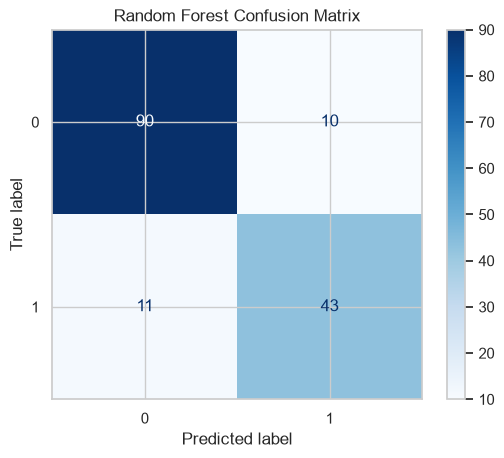

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()


In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)


              precision    recall  f1-score   support

           0       0.89      0.90      0.90       100
           1       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



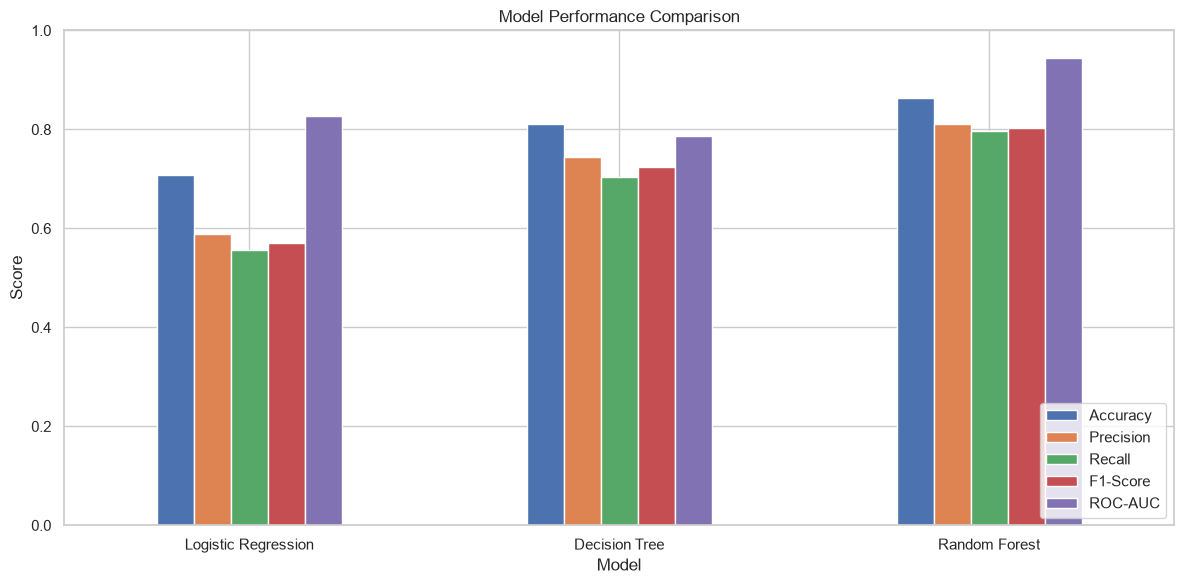

In [39]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [40]:
# Select Random Forest as the final model

final_model = random_forest

print("Final Model: Random Forest Classifier")


Final Model: Random Forest Classifier


## FINAL PREDICTION

In [43]:
# Generate final predictions
final_predictions = final_model.predict(X_test)

print("Final Predictions:")
print(final_predictions)


Final Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 0
 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 1
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]


In [44]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 120,
    "BloodPressure": 70,
    "SkinThickness": 25,
    "Insulin": 100,
    "BMI": 30.5,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 35
}])

prediction = final_model.predict(new_patient)[0]
probability = final_model.predict_proba(new_patient)[0][1]

print("Prediction:", prediction)
print("Probability:", round(probability, 4))


Prediction: 0
Probability: 0.11


In [45]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    final_model,
    "models/diabetes_random_forest.pkl"
)

print("Model saved successfully.")


Model saved successfully.
